In [31]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.patches as mpatches

from itertools import cycle

# Base directories
RUNS_DIR = "experiments/runs"

# Matplotlib style
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "figure.figsize": (5, 3.5)
})


In [32]:
def list_and_select(dir_glob, prompt="Select:"):
    files = sorted(
        glob.glob(dir_glob),
        key=lambda x: int(os.path.basename(x)) if os.path.basename(x).isdigit()
        else os.path.basename(x)
    )
    if not files:
        raise FileNotFoundError(f"No files found matching {dir_glob}")

    while True:
        choice = input(f"{prompt} (0-{len(files)-1}, Enter = latest): ").strip()
        if choice == "":
            return files[-1]
        try:
            idx = int(choice)
            if 1 <= idx <= len(files):
                return files[idx]
        except ValueError:
            pass
        print("Invalid selection, try again.")

run_dir = list_and_select(os.path.join(RUNS_DIR, "[0-9]*"), "Select run")
log_path = os.path.join(run_dir, "tomography.log")
print("Using log_path =", log_path)

if not os.path.exists(log_path):
    raise FileNotFoundError(f"{log_path} not found.")

Using log_path = experiments/runs/173/tomography.log


In [33]:
# Parse tomography.log into exp_data / exp_labels / exp_pm / order

def _tokens_to_complex_vector(tokens):
    """
    Convert a token list (like ['0.', '+0.j', '0.707+0.j', ...])
    into a numpy complex vector. Handles 1- and 2-token forms.
    """
    vec = []
    prev = None
    for tok in tokens:
        if tok == '':
            continue

        # compact complex 'a+bi' with 'j'
        if 'j' in tok and ('+' in tok[1:] or '-' in tok[1:]):
            try:
                vec.append(complex(tok))
                prev = None
                continue
            except Exception:
                pass

        # two-token form 'a.' '+b.j'
        if prev is not None and tok.endswith('j') and ('+' in tok or '-' in tok):
            try:
                c = complex(prev + tok)
                vec.append(c)
                prev = None
                continue
            except Exception:
                prev = None

        # '0.j' style
        if tok.endswith('j'):
            try:
                vec.append(complex(tok))
                prev = None
                continue
            except Exception:
                prev = None
                continue

        prev = tok

    return np.array(vec, dtype=complex)


def parse_experiment_fidelities(log_path):
    """
    Parse tomography.log for:
      - exp_data[exp_id]: list of fidelities (floats)
      - exp_labels[exp_id]: 'binary, binary, ...' (nonzero basis indices)
      - exp_pm[exp_id]: bool (Partial mixing)
      - order: list of exp_ids in chronological appearance
    """
    exp_data = {}
    exp_labels = {}
    exp_pm = {}
    order = []

    current_exp = None
    capture_original = False
    original_buf = []

    with open(log_path, "r") as f:
        for raw in f:
            line = raw.rstrip("\n")

            # Experiment ID
            m_exp = re.search(r"Experiment ID:\s+(\d+)", line)
            if m_exp:
                current_exp = int(m_exp.group(1))
                if current_exp not in exp_data:
                    exp_data[current_exp] = []
                    order.append(current_exp)
                capture_original = False
                original_buf = []
                continue

            # Partial mixing
            m_pm = re.search(r"Partial mixing:\s+(True|False)", line)
            if m_pm and current_exp is not None:
                exp_pm[current_exp] = (m_pm.group(1) == "True")
                continue

            # Start capturing original vector
            if "Original:" in line:
                capture_original = True
                original_buf = []
                continue

            # Capture original state vector until closing ']'
            if capture_original:
                original_buf.append(line.strip())
                if ']' in line:
                    joined = " ".join(original_buf)
                    inside = joined[joined.find('[')+1: joined.rfind(']')]
                    token_str = inside.replace(",", " ")
                    tokens = token_str.split()
                    vec = _tokens_to_complex_vector(tokens)

                    L = len(vec)
                    if L > 0 and (L & (L - 1)) == 0:
                        n_qubits = int(np.log2(L))
                        nz = np.where(np.abs(vec) > 1e-8)[0]
                        label = ", ".join(
                            format(i, f"0{n_qubits}b") for i in nz)
                        exp_labels[current_exp] = label
                    elif current_exp in (30, 31):
                        n_qubits = 10
                        label = '0000000000, 1111111111'
                        exp_labels[current_exp] = label
                    else:
                        print(f"[warn] Weird state length {L} for exp {current_exp}")
                        

                    capture_original = False
                continue

            # Single fidelity
            # m_f = re.search(r"Fidelity:\s+([0-9.]+)", line)
            # if m_f and current_exp is not None:
            #     exp_data[current_exp].append(float(m_f.group(1)))
            #     continue

            # Bulk fidelities
            m_f2 = re.search(r"Fidelities:\s+(.*)", line)
            if m_f2 and current_exp is not None:
                vals = [float(x) for x in m_f2.group(1).split(",")]
                exp_data[current_exp].extend(vals)
                continue

    return exp_data, exp_labels, exp_pm, order


exp_data, exp_labels, exp_pm, order = parse_experiment_fidelities(log_path)

print("Experiments found:", order)
print("Labels:", exp_labels)
print("Partial mixing flags:", exp_pm)


Experiments found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Labels: {0: '000, 001', 1: '000, 001', 2: '000, 110', 3: '000, 110', 4: '000, 111', 5: '000, 111', 6: '000, 010, 100', 7: '000, 010, 100', 8: '000, 011, 100', 9: '000, 011, 100', 10: '000, 011, 110', 11: '000, 011, 110', 12: '00, 01, 10, 11', 13: '00, 01, 10, 11', 14: '0000, 1111', 15: '0000, 1111', 16: '011, 100', 17: '011, 100', 18: '00000, 11111', 19: '00000, 11111', 20: '001, 110', 21: '001, 110', 22: '000000, 111111', 23: '000000, 111111', 24: '0000000, 1111111', 25: '0000000, 1111111', 26: '00000000, 11111111', 27: '00000000, 11111111', 28: '000000000, 111111111', 29: '000000000, 111111111', 30: '0000000000, 1111111111', 31: '0000000000, 1111111111'}
Partial mixing flags: {0: False, 1: True, 2: False, 3: True, 4: False, 5: True, 6: False, 7: True, 8: False, 9: True, 10: False, 11: True, 12: False, 13: True, 14: False, 15: True, 16: False, 17: T

In [34]:
def rebuild_state_categories(exp_labels):
    """
    Build STATE_CATEGORY indexed by category_id, where each category
    corresponds to experiment IDs [2*g, 2*g+1].
    """
    STATE_CATEGORY = {}

    # number of categories = half the number of experiments
    n_cats = len(exp_labels) // 2

    for g in range(n_cats):
        exp_ent = 2*g      # ENT experiment
        exp_pm  = 2*g + 1  # PM experiment

        # Both ENT and PM share the same support, so read ENT only
        label_str = exp_labels[exp_ent]
        bitstrings = [s.strip() for s in label_str.split(",")]
        bitstrings = [b for b in bitstrings if len(b) > 0]

        n_qubits = len(bitstrings[0])
        support_size = len(bitstrings)

        # Compute Hamming if support_size == 2
        if support_size == 2:
            a, b = bitstrings
            h = sum(c1 != c2 for c1, c2 in zip(a, b))
        else:
            h = None

        # Classification rules
        if support_size == 2:
            if bitstrings[0] == "0"*n_qubits and bitstrings[1] == "1"*n_qubits:
                t = f"ghz_like_{n_qubits}"
            else:
                t = f"pair_h{h}"
        else:
            t = f"support_{support_size}"

        STATE_CATEGORY[g] = dict(
            exp_ids=[exp_ent, exp_pm],
            support_states=bitstrings,
            n_qubits=n_qubits,
            support=support_size,
            hamming=h,
            type=t,
        )

    return STATE_CATEGORY


STATE_CATEGORY = rebuild_state_categories(exp_labels=exp_labels)

In [35]:
STATE_CATEGORY

{0: {'exp_ids': [0, 1],
  'support_states': ['000', '001'],
  'n_qubits': 3,
  'support': 2,
  'hamming': 1,
  'type': 'pair_h1'},
 1: {'exp_ids': [2, 3],
  'support_states': ['000', '110'],
  'n_qubits': 3,
  'support': 2,
  'hamming': 2,
  'type': 'pair_h2'},
 2: {'exp_ids': [4, 5],
  'support_states': ['000', '111'],
  'n_qubits': 3,
  'support': 2,
  'hamming': 3,
  'type': 'ghz_like_3'},
 3: {'exp_ids': [6, 7],
  'support_states': ['000', '010', '100'],
  'n_qubits': 3,
  'support': 3,
  'hamming': None,
  'type': 'support_3'},
 4: {'exp_ids': [8, 9],
  'support_states': ['000', '011', '100'],
  'n_qubits': 3,
  'support': 3,
  'hamming': None,
  'type': 'support_3'},
 5: {'exp_ids': [10, 11],
  'support_states': ['000', '011', '110'],
  'n_qubits': 3,
  'support': 3,
  'hamming': None,
  'type': 'support_3'},
 6: {'exp_ids': [12, 13],
  'support_states': ['00', '01', '10', '11'],
  'n_qubits': 2,
  'support': 4,
  'hamming': None,
  'type': 'support_4'},
 7: {'exp_ids': [14, 15],

In [47]:
CATEGORY_MAP = {
    "hamming1_simple":     [0],            # |000>,|001>
    "hamming2_bell":       [1],            # |000>,|110>
    "two_support":         [0, 1, 2],     # GHZ3 + 011/100 + 110/001
    "three_support":       [3, 4, 5],      # nonstabilizer, 3-support states
    "ghz_chain":           [1, 2, 7, 9, 11, 12, 13, 14, 15],     # 2q, 3q,4q,5q,6q,7q,8q,9q,10q GHZ
    "process":             [6],            # 2-qubit process tomography
}


In [54]:
import numpy as np

experiment_stats = {}    # exp_id -> dict
state_stats = {}         # state_group -> dict

for exp_id, fids in exp_data.items():
    infid = 1 - np.array(fids)
    experiment_stats[exp_id] = {
        "median": np.median(infid),
        "min": np.min(infid),
        "max": np.max(infid),
        "p90": np.percentile(infid, 90),
        "n": len(infid),
        "scheme": "PM" if exp_pm.get(exp_id, False) else "CNOT",
        "state_group": exp_id // 2,
        "category": None,
    }

# assign category labels to experiments
for cat, groups in CATEGORY_MAP.items():
    for g in groups:
        for eid in [2*g, 2*g+1]:
            if eid in experiment_stats:
                experiment_stats[eid]["category"] = cat

# aggregate to state-group level (MST vs PM)
for g in range(len(STATE_CATEGORY)):
    mst_id = 2*g
    pm_id  = 2*g+1
    if mst_id not in experiment_stats or pm_id not in experiment_stats:
        continue
    state_stats[g] = {
        "category": experiment_stats[mst_id]["category"],
        "median_mst": experiment_stats[mst_id]["median"],
        "median_pm":  experiment_stats[pm_id]["median"],
        "p90_mst":    experiment_stats[mst_id]["p90"],
        "p90_pm":     experiment_stats[pm_id]["p90"],
        "min_mst": experiment_stats[mst_id]["min"],
        "max_mst": experiment_stats[mst_id]["max"],
        "min_pm":  experiment_stats[pm_id]["min"],
        "max_pm":  experiment_stats[pm_id]["max"],
    }
    print(mst_id, pm_id)
    mst_fids = np.array(exp_data[mst_id])
    pm_fids  = np.array(exp_data[pm_id])

    # Store full infidelity distributions
    state_stats[g]["all_mst"] = mst_fids
    state_stats[g]["all_pm"]  = pm_fids


len(state_stats)

0 1
2 3
4 5
6 7
8 9
10 11
12 13
14 15
16 17
18 19
20 21
22 23
24 25
26 27
28 29
30 31


16

In [55]:
for s, stats in state_stats.items():
    print(f"=== State Group {s} ===")
    print(f"Category        : {stats['category']}")
    print()
    
    print("MST Scheme:")
    print(f"  median        = {stats['median_mst']:.3e}")
    print(f"  min           = {stats['min_mst']:.3e}")
    print(f"  max           = {stats['max_mst']:.3e}")
    print(f"  p90           = {stats['p90_mst']:.3e}")
    print()
    
    print("PM Scheme:")
    print(f"  median        = {stats['median_pm']:.3e}")
    print(f"  min           = {stats['min_pm']:.3e}")
    print(f"  max           = {stats['max_pm']:.3e}")
    print(f"  p90           = {stats['p90_pm']:.3e}")



=== State Group 0 ===
Category        : two_support

MST Scheme:
  median        = 5.214e-05
  min           = 1.832e-05
  max           = 3.628e-04
  p90           = 1.283e-04

PM Scheme:
  median        = 5.214e-05
  min           = 1.832e-05
  max           = 3.628e-04
  p90           = 1.283e-04
=== State Group 1 ===
Category        : ghz_chain

MST Scheme:
  median        = 3.430e-05
  min           = 1.003e-05
  max           = 2.923e-04
  p90           = 9.770e-05

PM Scheme:
  median        = 7.503e-05
  min           = 1.643e-06
  max           = 3.079e-04
  p90           = 1.550e-04
=== State Group 2 ===
Category        : ghz_chain

MST Scheme:
  median        = 5.157e-05
  min           = 1.753e-05
  max           = 3.334e-04
  p90           = 1.284e-04

PM Scheme:
  median        = 1.553e-04
  min           = 2.015e-05
  max           = 4.890e-04
  p90           = 2.664e-04
=== State Group 3 ===
Category        : three_support

MST Scheme:
  median        = 7.275e-05
  min 

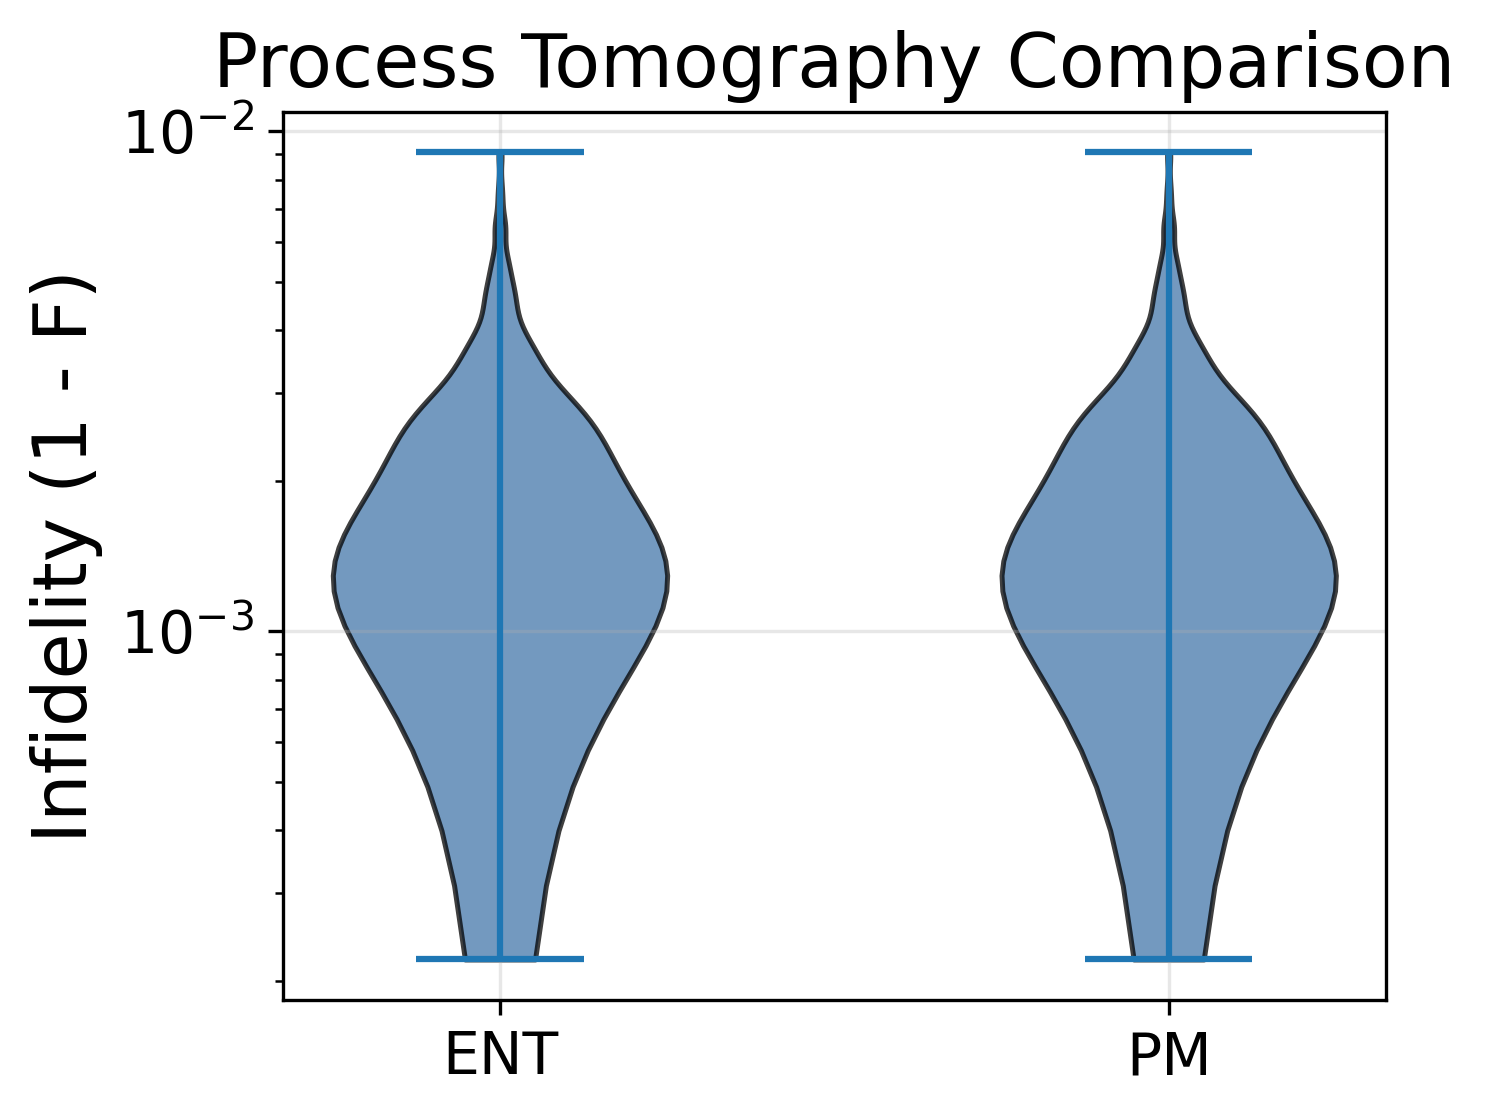

In [50]:
def plot_pm_vs_ent(pm_vals, ent_vals, ylabel="Infidelity (1 - F)", title=None):
    """
    Plots a clean log-scale violin comparison between PM and ENT.
    pm_vals and ent_vals should be 1D arrays of infidelities or errors.
    """

    pm_vals  = np.array(pm_vals)
    ent_vals = np.array(ent_vals)

    fig, ax = plt.subplots(figsize=(5,4))

    parts = ax.violinplot(
        [ent_vals, pm_vals],
        positions=[0, 1],
        showextrema=True,
    )

    # Style the violins
    for body in parts["bodies"]:
        body.set_facecolor("#4477AA")
        body.set_edgecolor("black")
        body.set_alpha(0.75)
        body.set_linewidth(1.2)

    # Axis formatting
    ax.set_xticks([0,1])
    ax.set_xticklabels(["ENT", "PM"])
    ax.set_ylabel(ylabel)
    ax.set_yscale("log")
    ax.grid(alpha=0.3)

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

g = 6   # your index
ent_vals = 1 - np.array(state_stats[g]["all_mst"])
pm_vals  = 1 - np.array(state_stats[g]["all_pm"])

plot_pm_vs_ent(pm_vals, ent_vals, title="Process Tomography Comparison")

[0, 1, 2] [3, 4, 5]


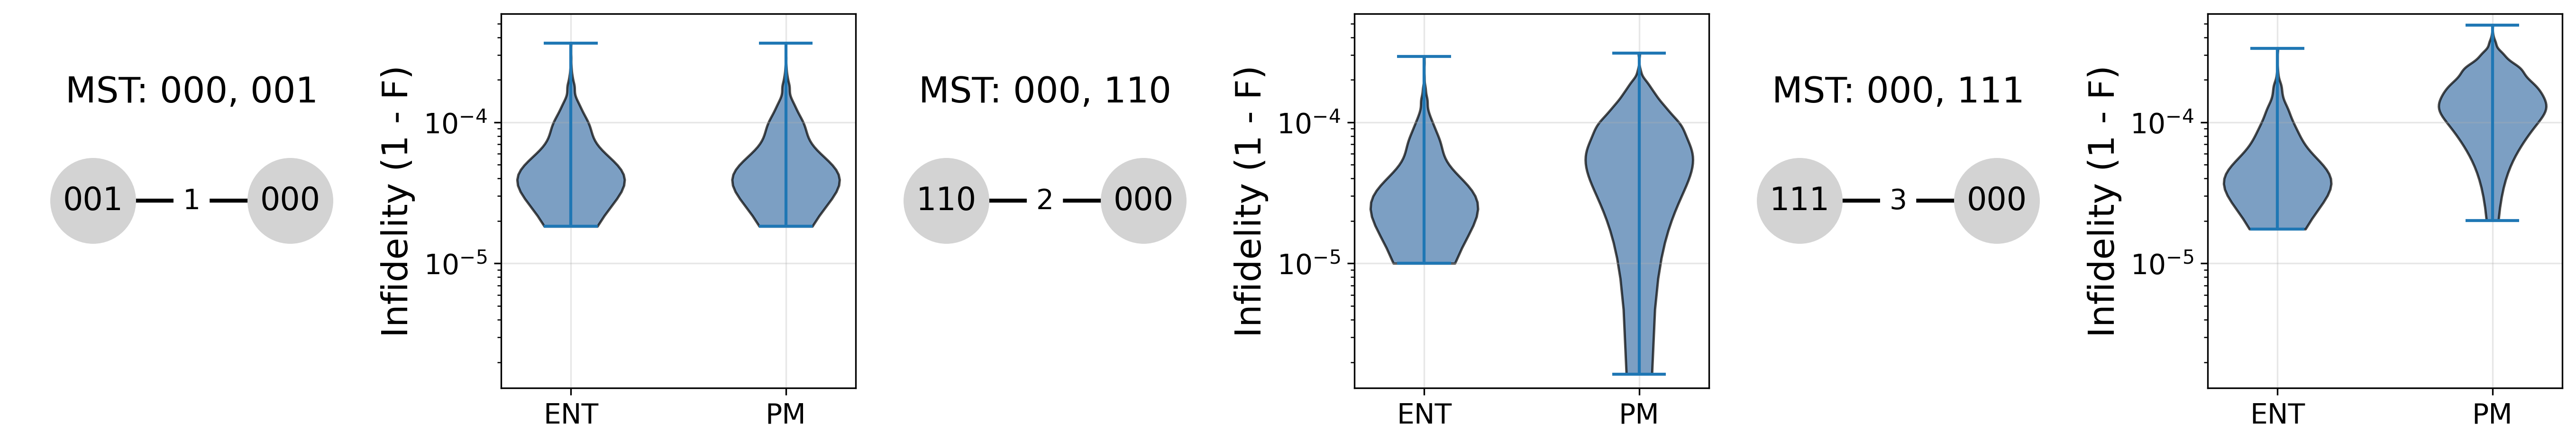

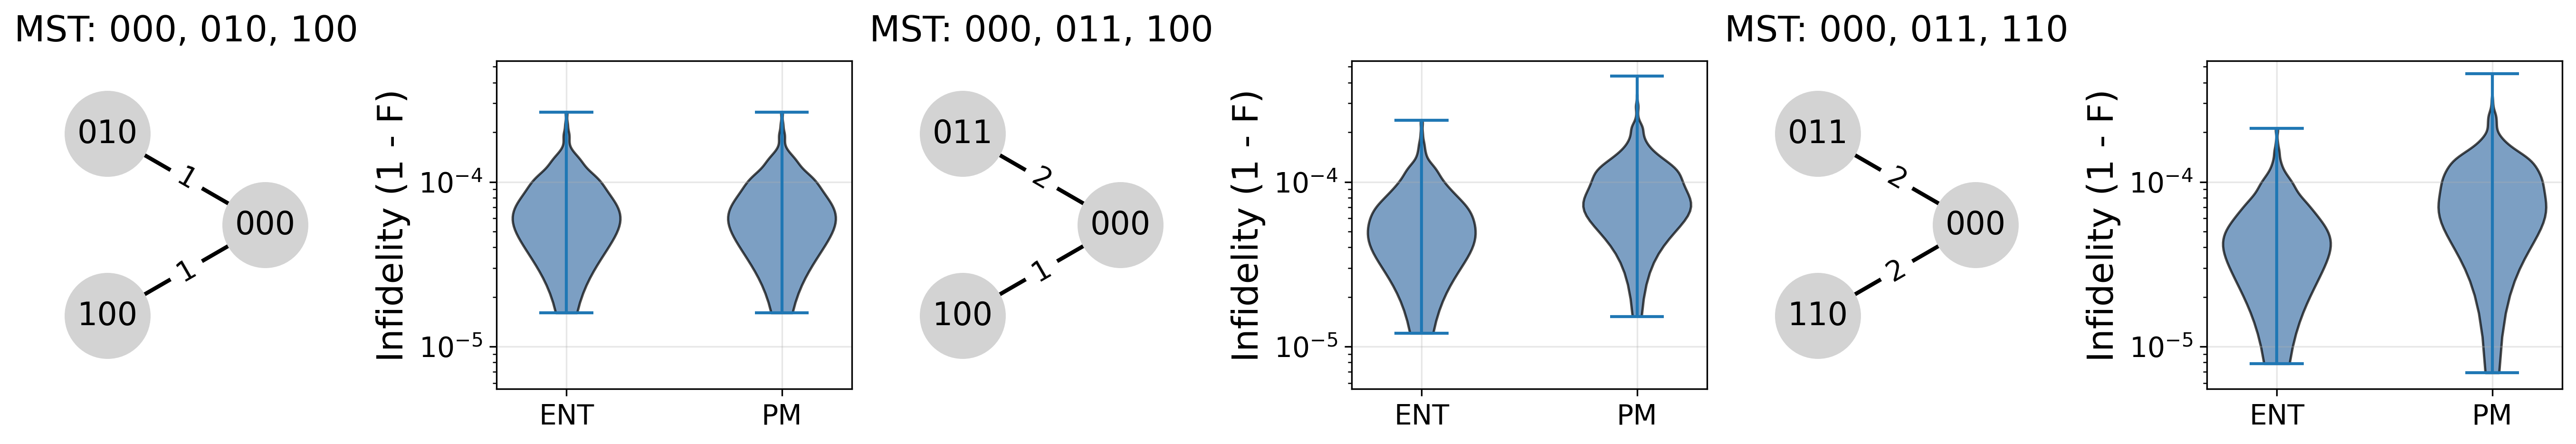

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# ----------------------------
# Global styling for readability
# ----------------------------
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.titlesize": 20,
})


def make_mst_graph(bitstrings):
    """
    Build an MST over support states with Hamming-distance weights.
    """
    G = nx.Graph()
    n = len(bitstrings[0])

    for b in bitstrings:
        G.add_node(b)

    for i in range(len(bitstrings)):
        for j in range(i+1, len(bitstrings)):
            b1, b2 = bitstrings[i], bitstrings[j]
            h = sum(c1 != c2 for c1, c2 in zip(b1, b2))
            G.add_edge(b1, b2, weight=h)

    return nx.minimum_spanning_tree(G, weight="weight")


def plot_category_panel(g, ax_graph, ax_violin, ylimits):
    # Parse labels → bitstrings
    label_str = exp_labels[2 * g]
    support = [s.strip() for s in label_str.split(",") if s.strip()]

    mst_inf = 1 - np.array(state_stats[g]["all_mst"])
    pm_inf  = 1 - np.array(state_stats[g]["all_pm"])

    # ----------------------------
    # MST GRAPH (left panel)
    # ----------------------------
    T = make_mst_graph(support)

    # compact, symmetric layout
    pos = nx.circular_layout(T)

    nx.draw(
        T, pos, ax=ax_graph,
        with_labels=True,
        node_size=1800,
        node_color="lightgray",
        font_size=16,
        width=2
    )

    edge_weights = nx.get_edge_attributes(T, "weight")
    nx.draw_networkx_edge_labels(
        T, pos, ax=ax_graph,
        edge_labels=edge_weights,
        font_size=14
    )

    # --- add padding so nodes / labels aren't clipped ---
    xs = np.array([p[0] for p in pos.values()])
    ys = np.array([p[1] for p in pos.values()])
    # if all nodes collapse to a point, avoid zero range
    dx = xs.max() - xs.min() if xs.max() > xs.min() else 1.0
    dy = ys.max() - ys.min() if ys.max() > ys.min() else 1.0
    pad = 0.4 * max(dx, dy)

    ax_graph.set_xlim(xs.min() - pad, xs.max() + pad)
    ax_graph.set_ylim(ys.min() - pad, ys.max() + pad)
    ax_graph.set_aspect("equal")
    ax_graph.set_axis_off()

    ax_graph.set_title(f"MST: {label_str}", pad=10)

    # ----------------------------
    # VIOLIN PLOT (right panel)
    # ----------------------------
    parts = ax_violin.violinplot(
        [mst_inf, pm_inf],
        positions=[0, 1],
        showextrema=True,
    )

    for body in parts["bodies"]:
        body.set_facecolor("#4477AA")
        body.set_alpha(0.7)
        body.set_edgecolor("black")
        body.set_linewidth(1.2)

    ax_violin.set_xticks([0, 1])
    ax_violin.set_xticklabels(["ENT", "PM"])
    ax_violin.set_ylabel("Infidelity (1 - F)")
    ax_violin.set_yscale("log")
    ax_violin.set_ylim(ylimits)
    ax_violin.grid(alpha=0.3)



def compute_global_limits(groups):
    """Compute global y-axis limits for shared scaling."""
    vals = []
    for g in groups:
        vals.append(1 - np.array(state_stats[g]["all_mst"]))
        vals.append(1 - np.array(state_stats[g]["all_pm"]))

    vals = np.concatenate(vals)
    vmin = vals[vals > 0].min() * 0.8
    vmax = vals.max() * 1.2
    return (vmin, vmax)


def plot_category_groups(groups, title="Category Comparison"):
    n_groups = len(groups)
    n_cols = 2 * n_groups

    ylimits = compute_global_limits(groups)

    fig, axes = plt.subplots(
        1, n_cols,
        figsize=(3.0 * n_cols, 3.0),
        constrained_layout=True
    )

    if n_cols == 2:
        axes = np.array([axes[0], axes[1]])

    for i, g in enumerate(groups):
        ax_graph = axes[2*i]
        ax_violin = axes[2*i + 1]
        plot_category_panel(g, ax_graph, ax_violin, ylimits)

    # fig.suptitle(title, fontsize=14, y=1.05)   # smaller title, tighter spacing
    plt.show()



# Example usage
groups_2 = CATEGORY_MAP["two_support"][:3]
groups_3 = CATEGORY_MAP["three_support"][:3]

print(groups_2, groups_3)

plot_category_groups(groups_2, title="2-Support States")
plot_category_groups(groups_3, title="3-Support States")


note that the CNOT method doesn't reconstruct from two samples, leading to better performance for CNOT. 

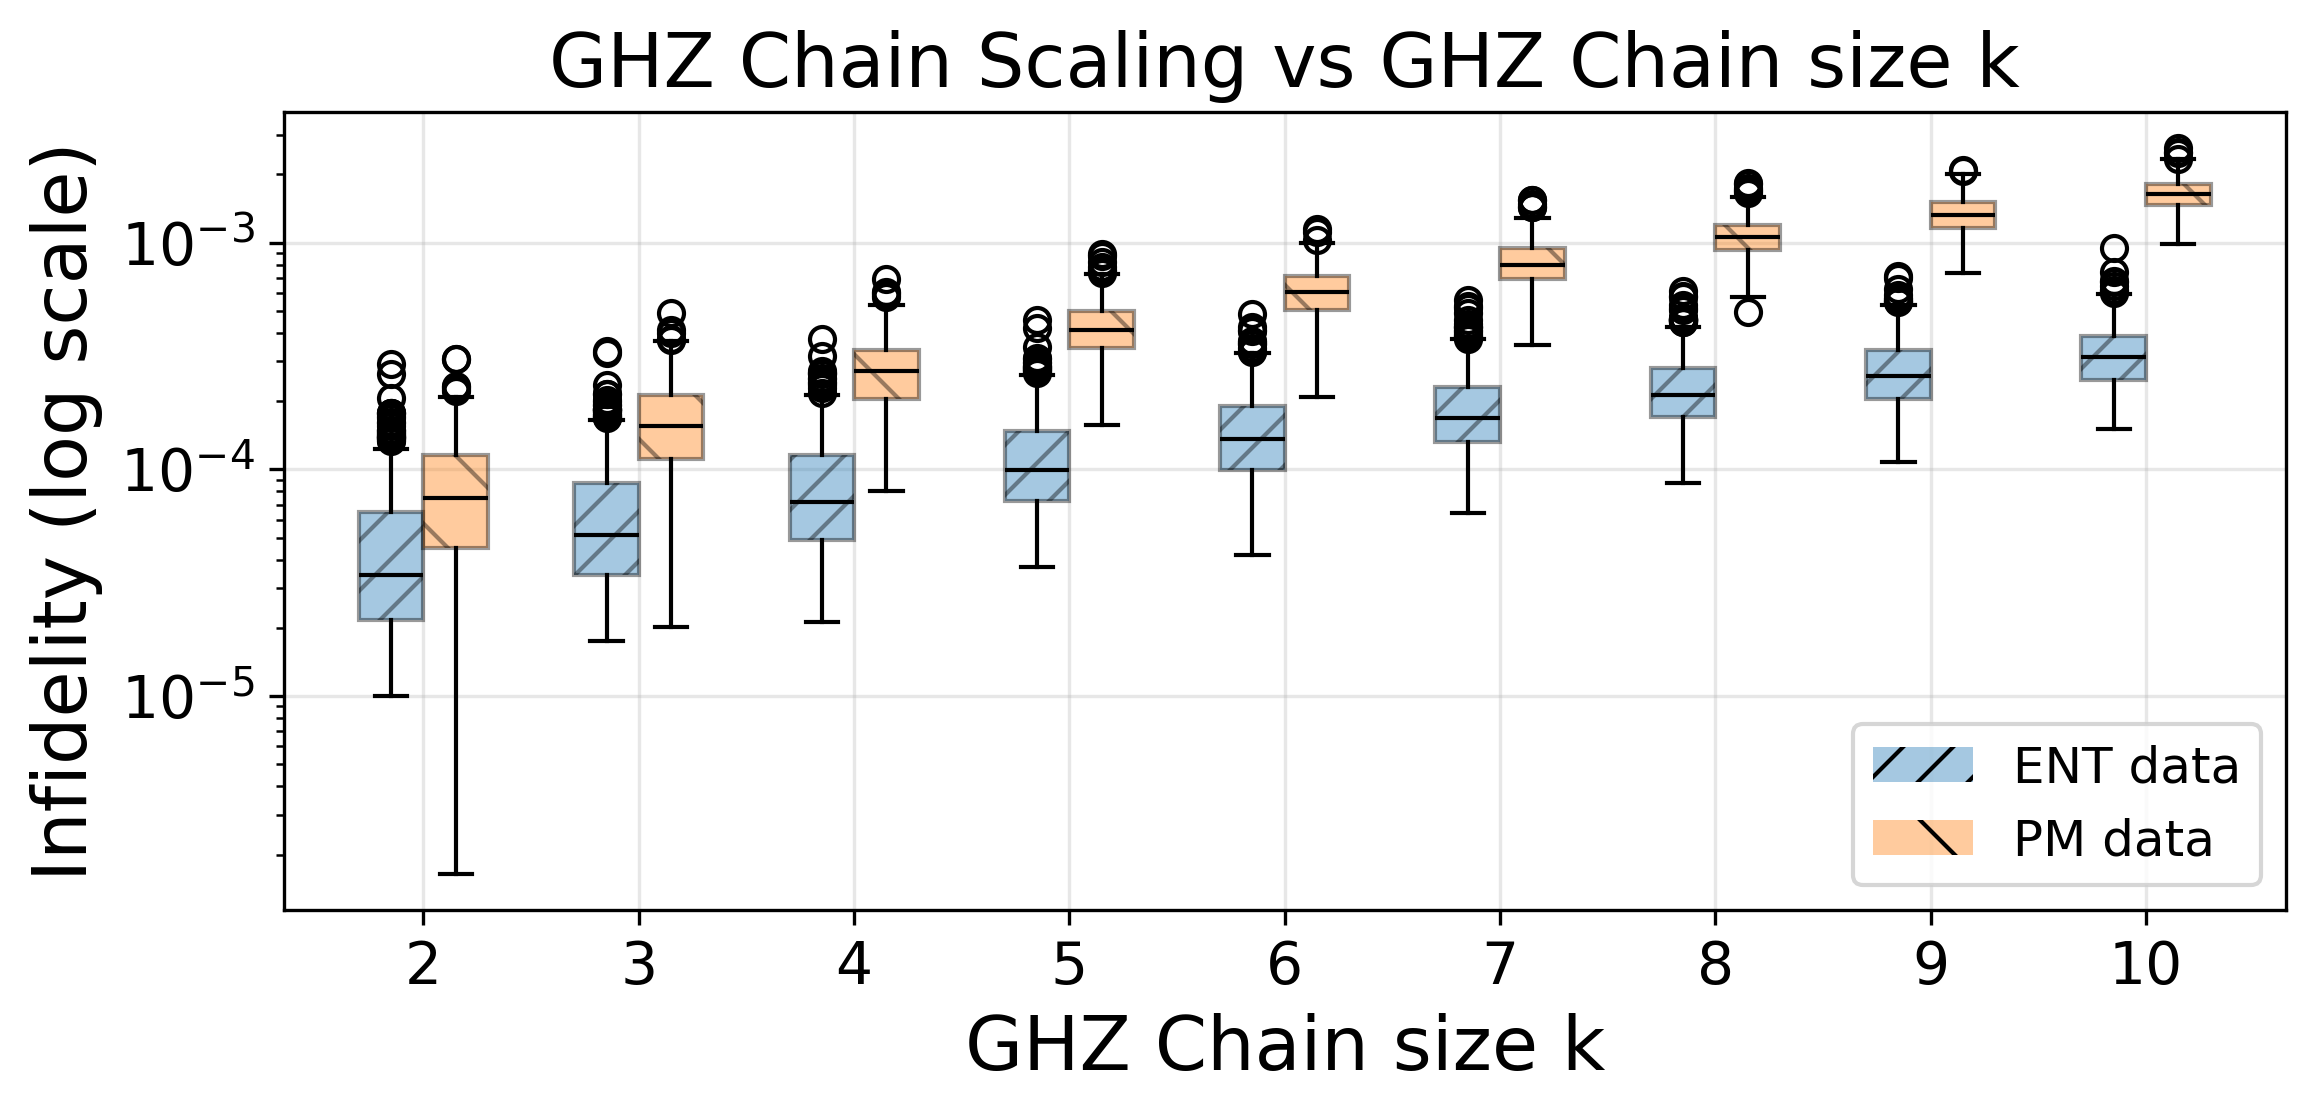

In [58]:
# ============================================================
# === Simple Noise Model Theories ============================
# ============================================================

def mst_simple(ns, p_1q, p_2q, p_meas, shots):
    """
    ENT/MST model (no fitting; uses physical error rates):

        - 2Q gate errors: (n - 1) * p_2q
        - 1Q gate errors: ~ 2 n * p_1q   (assume O(1) 1q gates per qubit)
        - readout errors: n * p_meas
        - shot noise:     sqrt(n / shots)

        I_MST(n) = [2 n p_1q + (n-1) p_2q] + sqrt(n / shots) + n p_meas
    """
    ns = np.asarray(ns, float)

    # crude gate-count model
    n_2q = (ns - 1.0)        # GHZ chain: n-1 CXs
    n_1q = 2.0 * ns          # assume ~2 single-qubit gates per qubit

    gate_term = n_1q * p_1q + n_2q * p_2q
    shot_term = np.sqrt(ns / shots)
    meas_term = ns * p_meas

    return gate_term + shot_term + meas_term


def pm_simple(ns, p_1q, p_2q, p_meas, shots, dim_alpha=1.0, base_dim=2.0):
    """
    PM model (no fitting; uses physical error rates):

        - same simple gate-count model for 1q/2q as ENT (can tweak later)
        - effective dimension grows as:
              D_eff(n) = base_dim * 2^(dim_alpha (n - n0))
        - shot noise: sqrt(D_eff / shots)
        - readout:    n * p_meas
        - gate noise: same as ENT here (for simplicity)

        I_PM(n) = [2 n p_1q + (n-1) p_2q] + sqrt(D_eff / shots) + n p_meas
    """
    ns = np.asarray(ns, float)
    n0 = ns.min()

    D_eff = base_dim * 2.0 ** (dim_alpha * (ns - n0))

    # crude gate-count model (can be adjusted if PM uses more/less gates)
    n_2q = (ns - 1.0)
    n_1q = 2.0 * ns

    gate_term = n_1q * p_1q + n_2q * p_2q
    shot_term = np.sqrt(D_eff / shots)
    meas_term = ns * p_meas

    return gate_term + shot_term + meas_term


# ============================================================
# === Main Plot Function =====================================
# ============================================================

def plot_simple_noise_scaling(
    n_min=2, n_max=12,
    p_1q=4.239e-4,
    p_2q=3.416e-3,
    p_meas=1e-2,
    shots=16384,
    dim_alpha=1.0,
    plot_fit = False,
):

    # -----------------------------------------
    # 1. Collect GHZ chain data
    # -----------------------------------------
    ghz_groups = sorted(CATEGORY_MAP["ghz_chain"])
    ns_data = np.arange(2, 2 + len(ghz_groups))  # GHZ chain sizes per group

    mask = (ns_data >= n_min) & (ns_data <= n_max)
    ns_used = ns_data[mask]
    ghz_used = [ghz_groups[i] for i in np.where(mask)[0]]

    mst_infids = [1 - np.array(state_stats[g]["all_mst"]) for g in ghz_used]
    pm_infids  = [1 - np.array(state_stats[g]["all_pm"])  for g in ghz_used]

    # -----------------------------------------
    # 2. Evaluate simple-model curves (no fitting)
    # -----------------------------------------
    # We’ll evaluate theory at exactly the n-values where we have data
    mst_curve_k = mst_simple(
        ns_used,
        p_1q=p_1q,
        p_2q=p_2q,
        p_meas=p_meas,
        shots=shots,
    )

    pm_curve_k = pm_simple(
        ns_used,
        p_1q=p_1q,
        p_2q=p_2q,
        p_meas=p_meas,
        shots=shots,
        dim_alpha=dim_alpha,
        base_dim=2.0,
    )

    # -----------------------------------------
    # 3. Fix x-axis indexing: use integer mixing dimension k
    # -----------------------------------------
    K = len(ns_used)
    ks = np.arange(2, K + 2)   # label them k = 2,3,... (or whatever you like)

    fig, ax = plt.subplots(figsize=(8, 4))

    color_mst = plt.rcParams['axes.prop_cycle'].by_key()['color'][0]
    color_pm  = plt.rcParams['axes.prop_cycle'].by_key()['color'][1]

    offset_mst = -0.15
    offset_pm  = +0.15

    mst_face = dict(facecolor=color_mst, alpha=0.4, hatch="//")
    pm_face  = dict(facecolor=color_pm,  alpha=0.4, hatch="\\")

    # -----------------------------------------
    # 4. Boxplots in k-space
    # -----------------------------------------
    for i, k in enumerate(ks):
        ax.boxplot(
            mst_infids[i],
            positions=[k + offset_mst],
            widths=0.3,
            patch_artist=True,
            boxprops=mst_face,
            medianprops=dict(color="black"),
        )
        ax.boxplot(
            pm_infids[i],
            positions=[k + offset_pm],
            widths=0.3,
            patch_artist=True,
            boxprops=pm_face,
            medianprops=dict(color="black"),
        )

    # -----------------------------------------
    # 5. Plot theory curves vs k
    # -----------------------------------------
    if plot_fit:
        ax.plot(ks, mst_curve_k, "--", color=color_mst, linewidth=2,
                label="ENT simple noise (1q+2q+RO+shots)")
        ax.plot(ks, pm_curve_k, "--", color=color_pm, linewidth=2,
                label="PM simple noise (1q+2q+RO+shots)")

    # -----------------------------------------
    # 6. Formatting for integer-mixing-dimension axis
    # -----------------------------------------
    ax.set_yscale("log")
    ax.set_xticks(ks)
    ax.set_xticklabels([str(k) for k in ks])
    ax.set_xlabel("GHZ Chain size k")
    ax.set_ylabel("Infidelity (log scale)")
    ax.set_title("GHZ Chain Scaling vs GHZ Chain size k")
    ax.grid(alpha=0.3)

    mst_patch = mpatches.Patch(facecolor=color_mst, alpha=0.4, hatch="//",
                               label="ENT data")
    pm_patch  = mpatches.Patch(facecolor=color_pm,  alpha=0.4, hatch="\\",
                               label="PM data")
    ax.legend(handles=[mst_patch, pm_patch], loc="lower right")

    plt.tight_layout()
    plt.show()


# ============================================================
# === Call it =================================================
# ============================================================

plot_simple_noise_scaling(
    n_min=2,
    n_max=15,
    p_1q=4.239e-4,   # from custom_params["p_1q"]
    p_2q=3.416e-3,   # from custom_params["p_2q"]
    p_meas=1e-2,     # from custom_params["p_meas"]
    shots=16384,
    dim_alpha=1.0,
    plot_fit=False
)

heatmap

In [42]:
import csv
import json

RUNS_DIR = "experiments/runs_noise_sweep"

def list_and_select(dir_glob, prompt="Select:"):
    files = sorted(
        glob.glob(dir_glob),
        key=lambda x: int(os.path.basename(x)) if os.path.basename(x).isdigit()
        else os.path.basename(x)
    )
    if not files:
        raise FileNotFoundError(f"No files found matching {dir_glob}")

    while True:
        choice = input(f"{prompt} (0-{len(files)-1}, Enter = latest): ").strip()
        if choice == "":
            return files[-1]
        try:
            idx = int(choice)
            if 1 <= idx <= len(files):
                return files[idx]
        except ValueError:
            pass
        print("Invalid selection, try again.")

run_dir = list_and_select(os.path.join(RUNS_DIR, "[0-9]*"), "Select run")
log_path = os.path.join(run_dir, "info.json")
print("Using log_path =", log_path)

if not os.path.exists(log_path):
    raise FileNotFoundError(f"{log_path} not found.")


Using log_path = experiments/runs_noise_sweep/4/info.json


In [43]:
def load_run_info(info_path):
    """
    Load Sacred run directory, returning the parsed info.json.
    Expected structure:
      run_dir/
         info.json
         config.json
         ...
    """
    if not os.path.isfile(info_path):
        raise FileNotFoundError(f"No info.json found in {run_dir}")

    with open(info_path, "r") as f:
        info = json.load(f)

    if "results" not in info:
        raise ValueError(f"'results' not found in {info_path}")

    return info["results"]


results = load_run_info(log_path)

In [44]:
p2_vals   = sorted({r["p_2q"] for r in results})
pm_vals   = sorted({r["p_meas"] for r in results})

print("2-qubit errors:", p2_vals)
print("Readout errors:", pm_vals)


2-qubit errors: [0.0001, 0.0001668100537200059, 0.0002782559402207126, 0.00046415888336127773, 0.000774263682681127, 0.001291549665014884, 0.002154434690031882, 0.003593813663804626, 0.005994842503189409, 0.01]
Readout errors: [0.001, 0.0015448591479026764, 0.002386589786858581, 0.0036869450645195733, 0.005695810810737686, 0.008799225435691074, 0.013593563908785255, 0.021000141557086554, 0.0324422607917163, 0.05011872336272722]


In [45]:
ENT = np.zeros((len(pm_vals), len(p2_vals)))
PM  = np.zeros((len(pm_vals), len(p2_vals)))

for r in results:
    i = pm_vals.index(r["p_meas"])
    j = p2_vals.index(r["p_2q"])
    ENT[i, j] = r["ENT_fidelity"]
    PM[i, j]  = r["PM_fidelity"]

DIFF  = PM - ENT
RATIO = PM / ENT


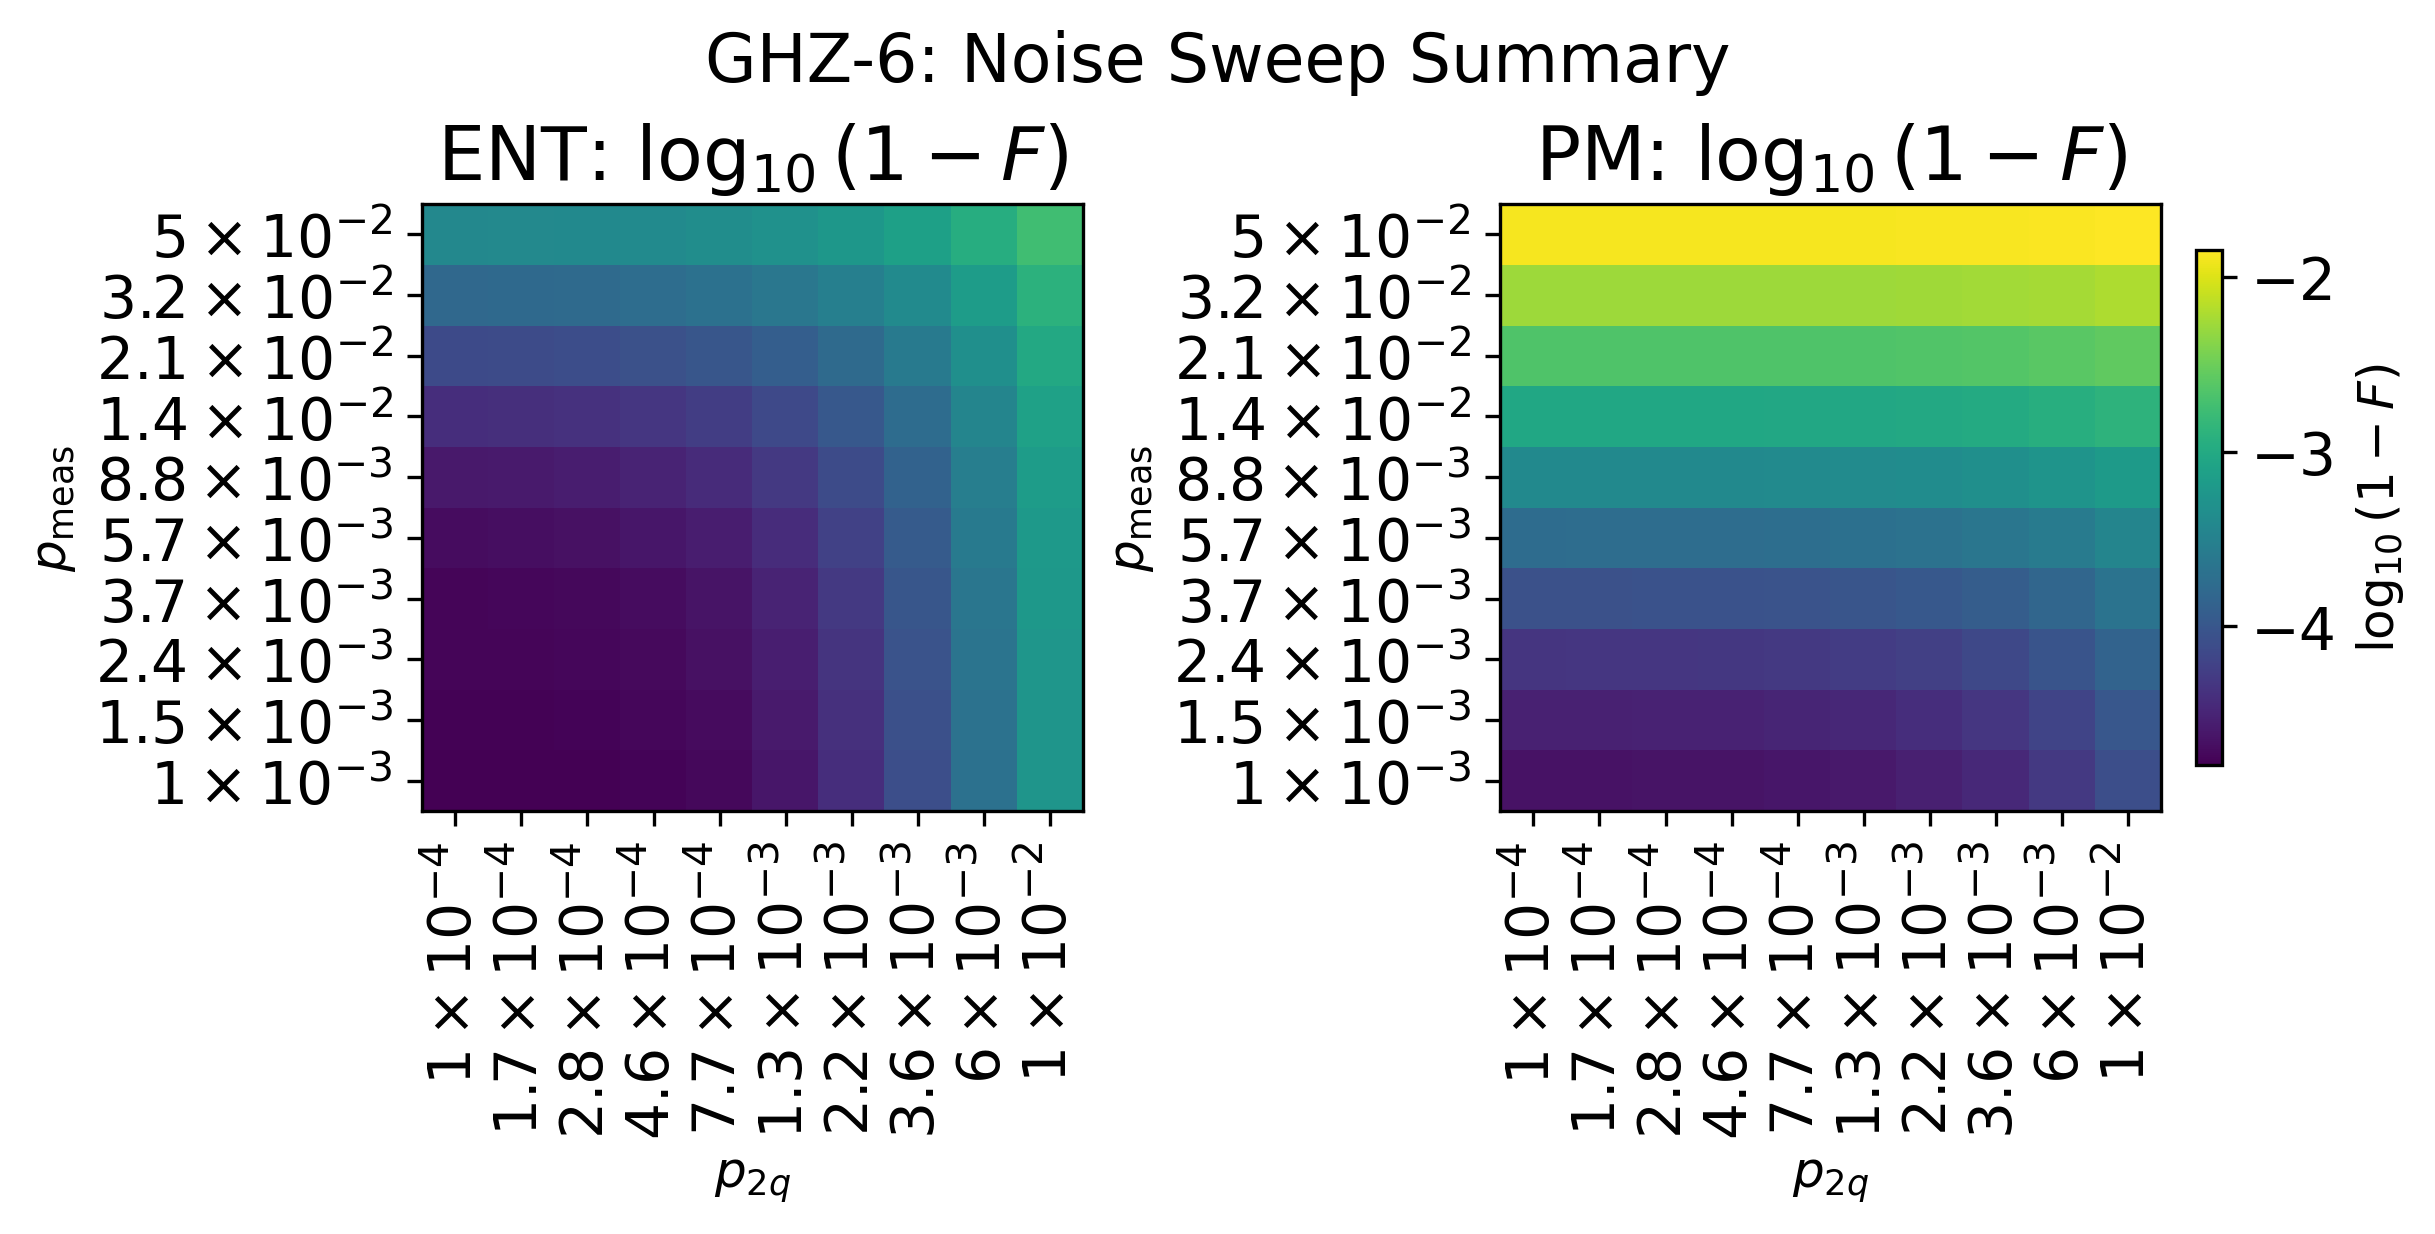

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

def latex_pow(v):
    """Format a number into mantissa × 10^{exp}, e.g. 0.053 → 5.3 × 10^{-2}."""
    if v == 0:
        return "$0$"
    exp = int(np.floor(np.log10(abs(v))))
    mant = v / (10**exp)
    # Format with a reasonable number of digits
    return fr"${mant:.2g} \times 10^{{{exp}}}$"

def plot_all_heatmaps(ENT, PM, DIFF, RATIO, p2_vals, pm_vals, ghz_size):
    """
    Improved plotting with:
      - LaTeX scientific notation on axes
      - cleaner tick labels
      - tighter colorbar spacing
    """

    eps = 1e-12
    ENT_log = np.log10(np.clip(1 - ENT, eps, None))
    PM_log  = np.log10(np.clip(1 - PM,  eps, None))

    # consistent scaling for ENT and PM
    log_min = min(ENT_log.min(), PM_log.min())
    log_max = max(ENT_log.max(), PM_log.max())

    fig, axes = plt.subplots(
        1, 2, figsize=(8, 4),
        constrained_layout=True
    )

    titles = ["ENT: $\\log_{10}(1-F)$", "PM: $\\log_{10}(1-F)$"]
    
    x_centers = np.log10(p2_vals)
    y_centers = np.log10(pm_vals)

    # derive pixel boundaries
    x_edges = np.linspace(x_centers[0] - (x_centers[1]-x_centers[0])/2,
                        x_centers[-1] + (x_centers[1]-x_centers[0])/2,
                        len(x_centers)+1)

    y_edges = np.linspace(y_centers[0] - (y_centers[1]-y_centers[0])/2,
                        y_centers[-1] + (y_centers[1]-y_centers[0])/2,
                        len(y_centers)+1)

    extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]


    # ------------------- Plot ENT -------------------
    im0 = axes[0].imshow(
        ENT_log, origin="lower", aspect="auto",
        cmap="viridis", extent=extent,
        vmin=log_min, vmax=log_max
    )
    axes[0].set_title(titles[0])

    # ------------------- Plot PM -------------------
    im1 = axes[1].imshow(
        PM_log, origin="lower", aspect="auto",
        cmap="viridis", extent=extent,
        vmin=log_min, vmax=log_max
    )
    axes[1].set_title(titles[1])

    # ------------------- Shared colorbar -------------------
    # pad reduces spacing from axes
    cbar = fig.colorbar(im1, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label("$\\log_{10}(1 - F)$", fontsize=12)

    # ------------------- Axis formatting -------------------
    for ax in axes:

        # ---- X axis ----
        xticks = np.log10(p2_vals)
        xticklabels = [latex_pow(v) for v in p2_vals]

        ax.xaxis.set_major_locator(FixedLocator(xticks))
        ax.xaxis.set_major_formatter(FixedFormatter(xticklabels))

        ax.set_xlabel("$p_{2q}$", fontsize=12)

        # ---- Y axis ----
        yticks = np.log10(pm_vals)
        yticklabels = [latex_pow(v) for v in pm_vals]

        ax.yaxis.set_major_locator(FixedLocator(yticks))
        ax.yaxis.set_major_formatter(FixedFormatter(yticklabels))

        ax.set_ylabel("$p_{\\mathrm{meas}}$", fontsize=12)

        ax.tick_params(axis='x', labelrotation=90)

    fig.suptitle(f"GHZ-{ghz_size}: Noise Sweep Summary", fontsize=16)

    plt.show()

    
plot_all_heatmaps(ENT, PM, DIFF, RATIO, p2_vals, pm_vals, 6)